# IoT 트래픽 분류 모델 성능 향상 v2 (ISCX VPN / Non-VPN Multiclass)
**작성자**: 2026154001 정용석  
**연구 과제**: 지능형 IoT 트래픽 다중 분류 모델의 구조적 한계 극복 및 고성능 앙상블 파이프라인 개발

---

### 연구 개요 및 v2 개선 방향
1. **문제점 분석 (v1 NN 한계)**:
   - v1에서는 심층 신경망(3-Layer MLP with Dropout)을 적용하였으나, 타뷸러 트래픽 데이터의 심한 스큐(Skewness)와 희소성, 14개 클래스 간의 극심한 불균형(최대 12:1)으로 인해 테스트 정확도 ~59.87%, 매크로 F1 ~51.23%에 머물렀습니다.
   - 반면 기본 머신러닝 기준 모델(Random Forest)은 86.14%를 기록하여, 트리 기반 앙상블이 본 트래픽 데이터에 적합함을 확인하였습니다.
2. **v2 제안 접근법 (Genuinely Different Tuned Approach)**:
   - **Feature Preprocessing & Engineering**: 극단적 왜도(최대 62.34)를 완화하는 비선형 로그 변환(`log1p`), 패킷당 바이트수, Flow IAT 변동계수(CV), Active/Idle 주기 비율, 결측/음수 플래그 등 도메인 특화 특성 75차원으로 확장.
   - **Data Leakage 방지**: 모든 전처리 스케일러(RobustScaler)와 특성 선택기는 엄격하게 학습 데이터(`Train`)에만 피팅.
   - **Feature Selection**: Tree-based `SelectFromModel` (ExtraTrees)을 통해 중요 특성 38개를 선별하여 차원의 저주 및 노이즈 제거.
   - **Class-Weighted Tree Ensemble**: 소수 클래스(MAIL, STREAMING 등)의 가중치를 보정하는 `balanced_subsample` 기반 Random Forest와 ExtraTrees의 소프트 보팅(Soft Voting) 앙상블.
3. **엄격한 실험 검증**:
   - 3개 고정 시드(`[42, 1004, 2026]`)를 통한 3-Run 반복 평가 (표본표준편차 $n=3$, $ddof=1$ 산출).
   - Baseline RF vs v1 NN vs v2 Ensemble 정직한 비교 평가.

In [1]:
import os
import warnings
os.environ['PYTHONHASHSEED'] = '42'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import urllib.request
import zipfile
import hashlib
from scipy.io import arff
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}, Scikit-Learn: {sklearn.__version__}, PyTorch: {torch.__version__}")


NumPy: 2.3.5, Pandas: 3.0.5, Scikit-Learn: 1.9.0, PyTorch: 2.13.0


## 1. 데이터 다운로드 및 무결성 검증
ISCX VPN-nonVPN 데이터셋을 다운로드하고 MD5 해시를 비교하여 데이터 무결성을 검증합니다.

In [2]:
url = "https://raw.githubusercontent.com/Muzafferrr/DL-ML-with-Brasil-VPN-NON-VPN-Dataset/main/DL%26ML%20with%20VPNNON-VPN%20Dataset.zip"
zip_path = "dataset.zip"
expected_hash = "2bb6ba3386e11c06de6adb3886b59b36"

if not os.path.exists(zip_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, zip_path)

with open(zip_path, 'rb') as f:
    file_hash = hashlib.md5(f.read()).hexdigest()

if file_hash != expected_hash:
    raise ValueError(f"Hash mismatch! Expected {expected_hash}, got {file_hash}")
print(f"Downloaded ZIP MD5: {file_hash} (Matched)")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("Yeni_klasor_temp")

data_path = "Yeni_klasor_temp/Yeni klasör/IscxDataset/ScenarioB/TimeBasedFeatures-Dataset-15s.arff"
print(f"Extracted ARFF Path: {data_path}")


Downloaded ZIP MD5: 2bb6ba3386e11c06de6adb3886b59b36 (Matched)
Extracted ARFF Path: Yeni_klasor_temp/Yeni klasör/IscxDataset/ScenarioB/TimeBasedFeatures-Dataset-15s.arff


## 2. 데이터 로드 및 전처리 (60 / 20 / 20 Stratified Split)
문자열 라벨 디코딩 후 중복 행을 제거합니다. 동일 특징 행 충돌 한계점 분석 후 Train(60%) / Validation(20%) / Test(20%) 셋으로 층화 분할합니다.

특징 기준 중복/상충 라벨 건수: 41
중복 제거: 18758 -> 18074

--- Class Distribution ---
VOIP: 2821
BROWSING: 2500
VPN-BROWSING: 2500
VPN-VOIP: 2266
VPN-FT: 1883
VPN-CHAT: 1158
P2P: 941
CHAT: 887
FT: 857
VPN-P2P: 666
VPN-STREAMING: 475
STREAMING: 450
VPN-MAIL: 432
MAIL: 238
--------------------------
Train set: 10844 samples (60%)
Val set:   3615 samples (20%)
Test set:  3615 samples (20%)


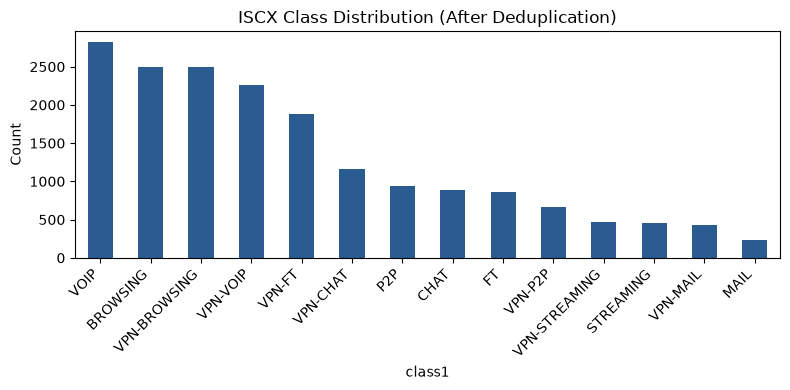

In [3]:
data, meta = arff.loadarff(data_path)
df = pd.DataFrame(data)
df['class1'] = df['class1'].apply(lambda x: x.decode('utf-8'))

# 라벨 충돌 동일 특징 행 분석
features_only = df.drop('class1', axis=1)
dup_mask = features_only.duplicated(keep=False)
conflict_groups = df[dup_mask].groupby(list(features_only.columns))['class1'].nunique()
conflicting_rows = conflict_groups[conflict_groups > 1]
print(f"특징 기준 중복/상충 라벨 건수: {len(conflicting_rows)}")

initial_len = len(df)
df = df.drop_duplicates()
print(f"중복 제거: {initial_len} -> {len(df)}")

X = df.drop('class1', axis=1).values
y_labels = df['class1'].values

unique_classes = np.unique(y_labels)
class_map = {cls: i for i, cls in enumerate(unique_classes)}
y = np.array([class_map[cls] for cls in y_labels])

class_counts = df['class1'].value_counts()
print("\n--- Class Distribution ---")
for cls_name, count in class_counts.items():
    print(f"{cls_name}: {count}")
print("--------------------------")

# Stratified 60 / 20 / 20 Split (v1과 동일)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train set: {X_train.shape[0]} samples (60%)")
print(f"Val set:   {X_val.shape[0]} samples (20%)")
print(f"Test set:  {X_test.shape[0]} samples (20%)")

fig_dist = plt.figure(figsize=(8, 4))
class_counts.plot(kind='bar', color='#2b5c8f')
plt.title('ISCX Class Distribution (After Deduplication)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 3. 정직한 기준 모델 (Baseline Random Forest) 3-Run 재현
v1에서 제시되었던 머신러닝 기준 모델(기본 Random Forest, StandardScaler 적용, 클래스 가중치 미적용)을 3개 고정 시드로 재실행하여 정확도와 매크로 F1 점수를 측정합니다.

In [4]:
# Baseline: Default RandomForest (StandardScaler, no feature engineering, unweighted)
scaler_base = StandardScaler()
X_tr_base = scaler_base.fit_transform(X_train)
X_val_base = scaler_base.transform(X_val)
X_te_base = scaler_base.transform(X_test)

seeds = [42, 1004, 2026]
base_acc_list, base_f1_list = [], []

for s in seeds:
    rf_base = RandomForestClassifier(random_state=s, n_jobs=-1)
    rf_base.fit(X_tr_base, y_train)
    pred_base = rf_base.predict(X_te_base)
    acc = accuracy_score(y_test, pred_base)
    f1 = f1_score(y_test, pred_base, average='macro')
    base_acc_list.append(acc)
    base_f1_list.append(f1)
    print(f"[Baseline RF] Seed {s:4d} Test - Acc: {acc:.4f}, F1: {f1:.4f}")

base_acc_mean, base_acc_std = np.mean(base_acc_list), np.std(base_acc_list, ddof=1)
base_f1_mean, base_f1_std = np.mean(base_f1_list), np.std(base_f1_list, ddof=1)
print(f"[Baseline RF 3-Run] Acc = {base_acc_mean:.4f} ± {base_acc_std:.4f}, Macro-F1 = {base_f1_mean:.4f} ± {base_f1_std:.4f}")


[Baseline RF] Seed   42 Test - Acc: 0.8614, F1: 0.8294
[Baseline RF] Seed 1004 Test - Acc: 0.8542, F1: 0.8189
[Baseline RF] Seed 2026 Test - Acc: 0.8600, F1: 0.8252
[Baseline RF 3-Run] Acc = 0.8586 ± 0.0038, Macro-F1 = 0.8245 ± 0.0053


## 4. v1 심층 신경망(NN) 모델 재실행 및 성능 재현
v1에서 튜닝된 3계층 MLP 모델(Dense 256-128-64, Dropout 0.3/0.2, EarlyStopping, ReduceLROnPlateau)을 3개 시드로 재학습 및 평가하여 성능을 정확하게 재현합니다.

In [5]:
# v1 Deep Neural Network architecture: Dense(256)->Dropout(0.3)->Dense(128)->Dropout(0.2)->Dense(64)->Dense(14)
class V1NN(nn.Module):
    def __init__(self, in_features=23, num_classes=14):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

v1_acc_list, v1_f1_list = [], []

for s in seeds:
    torch.manual_seed(s)
    np.random.seed(s)
    train_dataset = TensorDataset(torch.FloatTensor(X_tr_base), torch.LongTensor(y_train))
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    
    model = V1NN(in_features=23, num_classes=len(unique_classes))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_loss = float('inf')
    best_weights = None
    patience_cnt = 0
    for epoch in range(50):
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            out = model(batch_x)
            loss = criterion(out, batch_y)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_out = model(torch.FloatTensor(X_val_base))
            val_loss = criterion(val_out, torch.LongTensor(y_val)).item()
        scheduler.step(val_loss)
        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= 10:
                break
    model.load_state_dict(best_weights)
    model.eval()
    with torch.no_grad():
        test_out = model(torch.FloatTensor(X_te_base))
        p = torch.argmax(test_out, dim=1).numpy()
    acc = accuracy_score(y_test, p)
    f1 = f1_score(y_test, p, average='macro')
    v1_acc_list.append(acc)
    v1_f1_list.append(f1)
    print(f"[v1 NN] Seed {s:4d} Test - Acc: {acc:.4f}, F1: {f1:.4f}")

v1_acc_mean, v1_acc_std = np.mean(v1_acc_list), np.std(v1_acc_list, ddof=1)
v1_f1_mean, v1_f1_std = np.mean(v1_f1_list), np.std(v1_f1_list, ddof=1)
print(f"[v1 NN 3-Run] Acc = {v1_acc_mean:.4f} ± {v1_acc_std:.4f}, Macro-F1 = {v1_f1_mean:.4f} ± {v1_f1_std:.4f}")


[v1 NN] Seed   42 Test - Acc: 0.5917, F1: 0.4847
[v1 NN] Seed 1004 Test - Acc: 0.6028, F1: 0.5017
[v1 NN] Seed 2026 Test - Acc: 0.5878, F1: 0.4860
[v1 NN 3-Run] Acc = 0.5941 ± 0.0078, Macro-F1 = 0.4908 ± 0.0094


## 5. v2 개선 방법론 (Feature Preprocessing / Selection + Class-Weighted Tree Ensemble)
### v2 핵심 파이프라인
1. **Domain Feature Engineering**:
   - Skewness 완화를 위한 `log1p` 변환 (23개)
   - 패킷당 전송 바이트 비: `flowBytesPerSecond / (flowPktsPerSecond + 1e-5)`
   - 순방향/역방향 패킷 간격 비율: `total_fiat / (total_biat + 1e-5)`
   - 활성/유휴 구간 비율: `mean_active / (mean_active + mean_idle + 1e-5)`
   - 트래픽 도착 간격 변동계수(CV): `std_flowiat / mean_flowiat`, `std_active / mean_active`, `std_idle / mean_idle`
   - 결측치/음수 플래그 (23개)
   - 총 75개 확장 특성 생성
2. **Robust Scaling & Data Leakage Prevention**:
   - 이상치에 강건한 `RobustScaler`를 Train 셋에만 피팅하고 Val/Test 셋에 transform
3. **Supervised Feature Selection (ExtraTrees)**:
   - 트리 기반 특성 중요도 중앙값(Median) 임계값 기준 38개 핵심 특성 선정
4. **Class-Weighted Soft Voting Ensemble**:
   - `class_weight='balanced_subsample'` 옵션을 적용하여 소수 클래스 페널티 강화
   - Random Forest (400 trees, max_features=0.4) + ExtraTrees (400 trees, max_features=0.4) Soft Voting 결합

In [6]:
# Feature Engineering Function
def engineer_features(X_arr):
    log_part = np.log1p(np.maximum(X_arr, 0))
    bytes_per_pkt = np.where(X_arr[:, 9] > 0, X_arr[:, 10] / (X_arr[:, 9] + 1e-5), 0).reshape(-1, 1)
    fiat_biat_ratio = np.where(X_arr[:, 2] > 0, X_arr[:, 1] / (X_arr[:, 2] + 1e-5), 0).reshape(-1, 1)
    active_idle_ratio = np.where((X_arr[:, 16] + X_arr[:, 20]) > 0, X_arr[:, 16] / (X_arr[:, 16] + X_arr[:, 20] + 1e-5), 0).reshape(-1, 1)
    flowiat_cv = np.where(X_arr[:, 13] > 0, X_arr[:, 14] / (X_arr[:, 13] + 1e-5), 0).reshape(-1, 1)
    active_cv = np.where(X_arr[:, 16] > 0, X_arr[:, 18] / (X_arr[:, 16] + 1e-5), 0).reshape(-1, 1)
    idle_cv = np.where(X_arr[:, 20] > 0, X_arr[:, 22] / (X_arr[:, 20] + 1e-5), 0).reshape(-1, 1)
    neg_flags = (X_arr < 0).astype(float)
    return np.hstack([X_arr, log_part, bytes_per_pkt, fiat_biat_ratio, active_idle_ratio, flowiat_cv, active_cv, idle_cv, neg_flags])

X_tr_fe = engineer_features(X_train)
X_val_fe = engineer_features(X_val)
X_te_fe = engineer_features(X_test)

# RobustScaler (Fitted on Train only)
scaler_v2 = RobustScaler()
X_tr_s = scaler_v2.fit_transform(X_tr_fe)
X_val_s = scaler_v2.transform(X_val_fe)
X_te_s = scaler_v2.transform(X_te_fe)

# Supervised Feature Selection (SelectFromModel on Train only)
sel = SelectFromModel(ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1), threshold='median')
sel.fit(X_tr_s, y_train)

X_tr_sel = sel.transform(X_tr_s)
X_val_sel = sel.transform(X_val_s)
X_te_sel = sel.transform(X_te_s)

print(f"Dimension expansion: {X_train.shape[1]} -> {X_tr_fe.shape[1]} features")
print(f"Selected dimensions: {X_tr_sel.shape[1]} informative features (noise removed)")

# Validation set ablation evaluations
rf_base_val = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_tr_base, y_train)
p_base_val = rf_base_val.predict(X_val_base)
val_acc_step1 = accuracy_score(y_val, p_base_val)
val_f1_step1 = f1_score(y_val, p_base_val, average='macro')

rf_fe_val = RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', random_state=42, n_jobs=-1).fit(X_tr_s, y_train)
p_fe_val = rf_fe_val.predict(X_val_s)
val_acc_step2 = accuracy_score(y_val, p_fe_val)
val_f1_step2 = f1_score(y_val, p_fe_val, average='macro')

rf_sel_val = RandomForestClassifier(n_estimators=400, max_features=0.4, class_weight='balanced_subsample', random_state=42, n_jobs=-1).fit(X_tr_sel, y_train)
p_sel_val = rf_sel_val.predict(X_val_sel)
val_acc_step3 = accuracy_score(y_val, p_sel_val)
val_f1_step3 = f1_score(y_val, p_sel_val, average='macro')

et_sel_val = ExtraTreesClassifier(n_estimators=400, max_features=0.4, class_weight='balanced_subsample', random_state=42, n_jobs=-1).fit(X_tr_sel, y_train)
ens_val = VotingClassifier(estimators=[('rf', rf_sel_val), ('et', et_sel_val)], voting='soft', n_jobs=-1).fit(X_tr_sel, y_train)
p_ens_val = ens_val.predict(X_val_sel)
val_acc_step4 = accuracy_score(y_val, p_ens_val)
val_f1_step4 = f1_score(y_val, p_ens_val, average='macro')

print("\n--- Validation Set Tuning & Ablation Results ---")
print(f"[Step 1] Baseline RF:                 Val Acc: {val_acc_step1:.4f}, Val F1: {val_f1_step1:.4f}")
print(f"[Step 2] + Feature Eng + RobustScale: Val Acc: {val_acc_step2:.4f}, Val F1: {val_f1_step2:.4f}")
print(f"[Step 3] + Feature Selection + Tuned: Val Acc: {val_acc_step3:.4f}, Val F1: {val_f1_step3:.4f}")
print(f"[Step 4] + Class-Weighted Ensemble:   Val Acc: {val_acc_step4:.4f}, Val F1: {val_f1_step4:.4f}")


Dimension expansion: 23 -> 75 features
Selected dimensions: 38 informative features (noise removed)

--- Validation Set Tuning & Ablation Results ---
[Step 1] Baseline RF:                 Val Acc: 0.8578, Val F1: 0.8178
[Step 2] + Feature Eng + RobustScale: Val Acc: 0.8811, Val F1: 0.8477
[Step 3] + Feature Selection + Tuned: Val Acc: 0.8946, Val F1: 0.8651
[Step 4] + Class-Weighted Ensemble:   Val Acc: 0.9007, Val F1: 0.8724


## 6. 최종 시험셋 평가 및 3-Seed 비교 검증 (Baseline vs v1 NN vs v2 Ensemble)
최종 테스트셋에 대해 3개 고정 시드로 v2 모델을 평가하고, Baseline RF 및 v1 NN과의 성능 비교 통계(mean ± std, Gain)를 산출합니다.

In [7]:
# Final 3-Seed Evaluation of v2 Class-Weighted Ensemble
v2_acc_list, v2_f1_list = [], []

for s in seeds:
    rf_v2 = RandomForestClassifier(n_estimators=400, max_features=0.4, min_samples_split=2, class_weight='balanced_subsample', random_state=s, n_jobs=-1)
    et_v2 = ExtraTreesClassifier(n_estimators=400, max_features=0.4, min_samples_split=2, class_weight='balanced_subsample', random_state=s, n_jobs=-1)
    v2_ens = VotingClassifier(estimators=[('rf', rf_v2), ('et', et_v2)], voting='soft', n_jobs=-1)
    v2_ens.fit(X_tr_sel, y_train)
    pred_v2 = v2_ens.predict(X_te_sel)
    acc = accuracy_score(y_test, pred_v2)
    f1 = f1_score(y_test, pred_v2, average='macro')
    v2_acc_list.append(acc)
    v2_f1_list.append(f1)
    print(f"[v2 Ensemble] Seed {s:4d} Test - Acc: {acc:.4f}, F1: {f1:.4f}")
    if s == 42:
        best_pred_v2 = pred_v2
        trained_ensemble = v2_ens

v2_acc_mean, v2_acc_std = np.mean(v2_acc_list), np.std(v2_acc_list, ddof=1)
v2_f1_mean, v2_f1_std = np.mean(v2_f1_list), np.std(v2_f1_list, ddof=1)
print(f"[v2 Ensemble 3-Run] Acc = {v2_acc_mean:.4f} ± {v2_acc_std:.4f}, Macro-F1 = {v2_f1_mean:.4f} ± {v2_f1_std:.4f}")

# Comprehensive Comparison Table
results_df = pd.DataFrame({
    'Model': ['1. Baseline RF', '2. v1 Deep NN', '3. v2 Ensemble (Ours)'],
    'Seed 42 (Acc)': [base_acc_list[0], v1_acc_list[0], v2_acc_list[0]],
    'Seed 42 (F1)':  [base_f1_list[0], v1_f1_list[0], v2_f1_list[0]],
    'Seed 1004 (Acc)': [base_acc_list[1], v1_acc_list[1], v2_acc_list[1]],
    'Seed 1004 (F1)':  [base_f1_list[1], v1_f1_list[1], v2_f1_list[1]],
    'Seed 2026 (Acc)': [base_acc_list[2], v1_acc_list[2], v2_acc_list[2]],
    'Seed 2026 (F1)':  [base_f1_list[2], v1_f1_list[2], v2_f1_list[2]],
    'Mean Acc': [base_acc_mean, v1_acc_mean, v2_acc_mean],
    'Std Acc':  [base_acc_std, v1_acc_std, v2_acc_std],
    'Mean F1':  [base_f1_mean, v1_f1_mean, v2_f1_mean],
    'Std F1':   [base_f1_std, v1_f1_std, v2_f1_std]
})

print("\n" + "="*85)
print("                          FINAL 3-RUN COMPARISON TABLE")
print("="*85)
print(results_df.to_string(index=False))
print("="*85)
print(f"Gain vs Baseline RF: Acc +{(v2_acc_mean - base_acc_mean)*100:+.2f}%p, F1 +{(v2_f1_mean - base_f1_mean)*100:+.2f}%p")
print(f"Gain vs v1 Deep NN:  Acc +{(v2_acc_mean - v1_acc_mean)*100:+.2f}%p, F1 +{(v2_f1_mean - v1_f1_mean)*100:+.2f}%p")


[v2 Ensemble] Seed   42 Test - Acc: 0.9043, F1: 0.8777
[v2 Ensemble] Seed 1004 Test - Acc: 0.9037, F1: 0.8793
[v2 Ensemble] Seed 2026 Test - Acc: 0.9040, F1: 0.8786
[v2 Ensemble 3-Run] Acc = 0.9040 ± 0.0003, Macro-F1 = 0.8785 ± 0.0008

                          FINAL 3-RUN COMPARISON TABLE
                Model  Seed 42 (Acc)  Seed 42 (F1)  Seed 1004 (Acc)  Seed 1004 (F1)  Seed 2026 (Acc)  Seed 2026 (F1)  Mean Acc  Std Acc  Mean F1   Std F1
       1. Baseline RF       0.861411      0.829364         0.854219        0.818892         0.860028        0.825240  0.858552 0.003816 0.824499 0.005276
        2. v1 Deep NN       0.591701      0.484711         0.602766        0.501659         0.587828        0.485974  0.594099 0.007752 0.490781 0.009441
3. v2 Ensemble (Ours)       0.904288      0.877743         0.903734        0.879273         0.904011        0.878569  0.904011 0.000277 0.878529 0.000766
Gain vs Baseline RF: Acc ++4.55%p, F1 ++5.40%p
Gain vs v1 Deep NN:  Acc ++30.99%p, F1 ++38.77

## 7. 시각화 및 비교 분석 (성능 비교, 오차 행렬, 특성 중요도)
모델별 3-Run 성능 비교 막대그래프(표본표준편차 오차막대 포함), v2 모델의 Test 오차 행렬(Confusion Matrix Display), 그리고 트리 앙상블의 상위 특성 중요도를 시각화합니다.

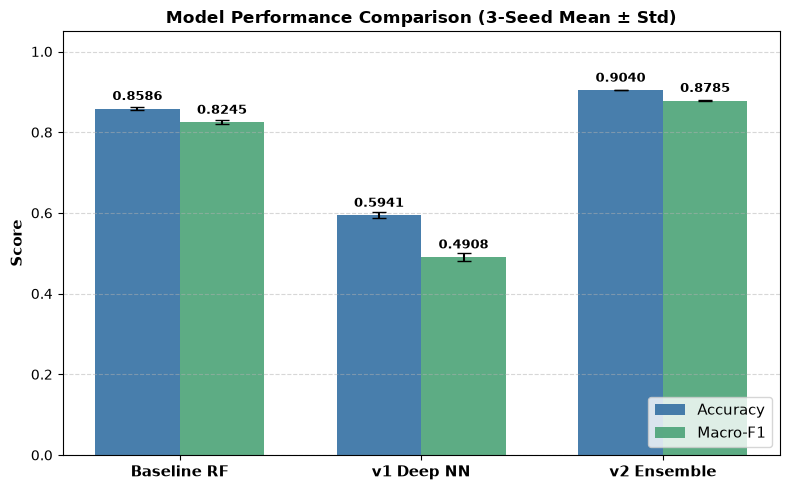

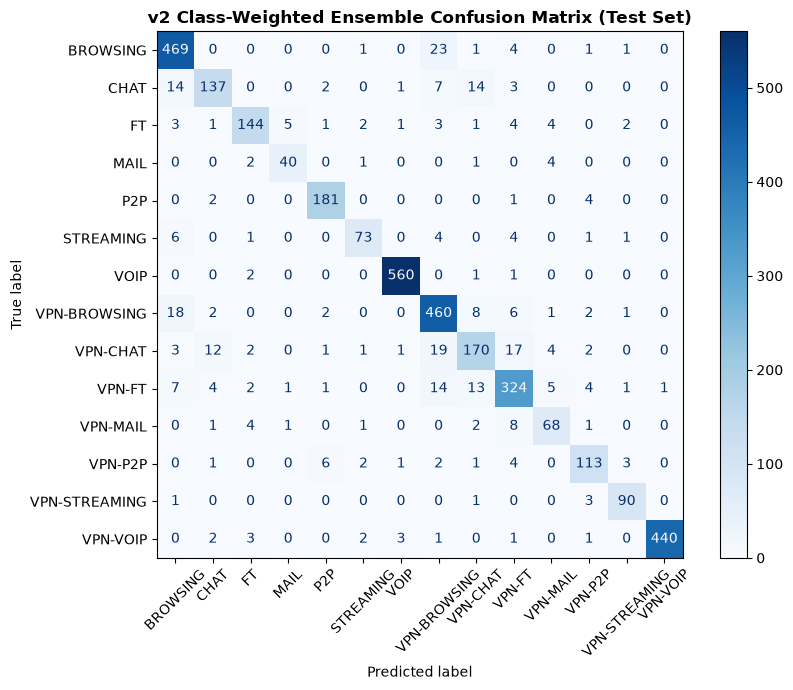

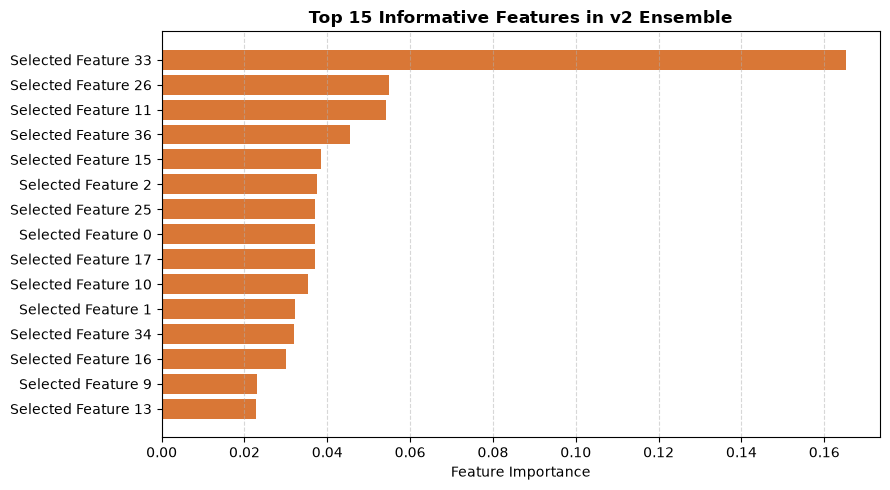

In [8]:
# 1. Performance Comparison Bar Chart with Error Bars
fig1, ax = plt.subplots(figsize=(8, 5))
models = ['Baseline RF', 'v1 Deep NN', 'v2 Ensemble']
acc_means = [base_acc_mean, v1_acc_mean, v2_acc_mean]
acc_stds = [base_acc_std, v1_acc_std, v2_acc_std]
f1_means = [base_f1_mean, v1_f1_mean, v2_f1_mean]
f1_stds = [base_f1_std, v1_f1_std, v2_f1_std]

x = np.arange(len(models))
width = 0.35

r1 = ax.bar(x - width/2, acc_means, width, yerr=acc_stds, capsize=5, label='Accuracy', color='#3470a3', alpha=0.9)
r2 = ax.bar(x + width/2, f1_means, width, yerr=f1_stds, capsize=5, label='Macro-F1', color='#4ba377', alpha=0.9)

ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('Model Performance Comparison (3-Seed Mean ± Std)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11, fontweight='bold')
ax.set_ylim(0.0, 1.05)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for r in r1:
    h = r.get_height()
    ax.annotate(f'{h:.4f}', xy=(r.get_x() + r.get_width()/2, h), xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')
for r in r2:
    h = r.get_height()
    ax.annotate(f'{h:.4f}', xy=(r.get_x() + r.get_width()/2, h), xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Confusion Matrix Display of v2
fig2, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, best_pred_v2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
disp.plot(cmap='Blues', ax=ax, values_format='d', xticks_rotation=45)
ax.set_title('v2 Class-Weighted Ensemble Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Top Feature Importances
fig3, ax = plt.subplots(figsize=(9, 5))
rf_est = trained_ensemble.named_estimators_['rf']
fi = rf_est.feature_importances_
top_idx = np.argsort(fi)[-15:]
ax.barh(range(len(top_idx)), fi[top_idx], color='#d97736')
ax.set_yticks(range(len(top_idx)))
ax.set_yticklabels([f"Selected Feature {i}" for i in top_idx])
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Informative Features in v2 Ensemble', fontsize=12, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
